# Baseline Model

This notebook explores the pretrained embeddings produced by the DINOv2 ViT-S/14 model (approximately 22 million parameters). DINOv2 is a self-supervised Vision Transformer that has demonstrated strong performance across a wide range of computer vision tasks, including anomaly detection.

The model divides an image into 14×14 pixel patches and produces a global image representation through the CLS token. In addition, patch-level embeddings can be extracted to provide local representations of different image regions.

The purpose of this notebook is to:

1. Evaluate several anomaly scoring methods using the extracted CLS embeddings:
- Centroid Distance
- K-Nearest Neighbours (KNN)
- Mahalanobis Distance
2. Analyse the distribution of anomaly scores for normal and defective samples to determine how well each method separates the two classes.
3. Compare methods using AUROC to identify the most effective baseline anomaly scoring approach.
4. Identify categories that are already well separated within the embedding space, as well as categories that remain challenging and may benefit from additional experimentation.

The results obtained in this notebook will serve as a baseline against which future approaches, including patch-level embeddings, hybrid representations, and semi-supervised methods, can be compared.

In [ ]:
import os 

import torch
import pandas as pd 
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import faiss
import pickle

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

from pathlib import Path

ROOT = Path.cwd().parents[1]

EMBED_PATH = ROOT / "data/embeddings/anomaly_head_embeds"
EMBED_NAME = EMBED_PATH.stem

IMAGE_DIR = ROOT / "images/baseline" / EMBED_NAME
CACHE_DIR = ROOT / "data/cache" / EMBED_NAME
RESULTS_DIR = ROOT / "data/results" / EMBED_NAME

In [2]:
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [3]:
cls_tokens = torch.load(EMBED_PATH/"cls.pt", weights_only=False)

conn = sqlite3.connect(ROOT / "data/sql/metadata.db")

meta = pd.read_sql_query("SELECT * FROM meta", conn)

conn.close()

## 1. Evaluate several anomaly scoring methods using the extracted CLS embeddings

Metrics chosen include:

- **Centroid Distance:** Computes the Euclidean distance between each test embedding and the centroid (mean embedding) of the corresponding training category.

- **K-Nearest Neighbours (KNN):** Computes the distance between each test embedding and its K nearest training embeddings (K=5). The anomaly score is taken as the distance to the closest neighbour.

- **Average KNN:** Computes the average distance between each test embedding and its K nearest training embeddings.

- **Mahalanobis Distance** - Computes the distance between each test embedding and the training distribution while accounting for the covariance structure of the embedding space.


In [4]:
results = {}

results_path = RESULTS_DIR / "cls_results.pkl"

if results_path.exists():
    with open(results_path, "rb") as f:
        results = pickle.load(f)
else:
    for category in meta["category"].unique():
        train_cls = cls_tokens[
            (meta["category"] == category)
            & (meta["split"] == "train")
        ]

        centroid = train_cls.mean(axis=0)

        covariance = np.cov(train_cls.T)
        covariance += np.eye(covariance.shape[0]) * 1e-6 # I matrix, added to help with regularisation
        cov_inv = np.linalg.pinv(covariance) # Incase matrix cannot be inverted

        test_cls = cls_tokens[(meta["category"] == category) & (meta["split"] == "test")]
        test_labels = meta[(meta["category"] == category) & (meta["split"] == "test")]["label"]

        diff = test_cls - centroid
        cen_scores = np.linalg.norm(diff, axis=1) # Axis 1 ensures it does not get the norm for all embeddings as one
        
        index = faiss.IndexFlatL2(train_cls.shape[1])
        index.add(train_cls.astype("float32"))

        D, I = index.search(
            test_cls.astype("float32"),
            k=5
        )

        nn_scores = D[:, 0] # Get closest distance
        avg_nn_scores = D.mean(axis=1)

        mal_scores = np.sqrt(
            np.einsum(
                "ij, jk, ik->i",
                diff,
                cov_inv,
                diff
            )
        )

        results[category] = {
            "train": train_cls,
            "test": test_cls,
            "centroid": centroid,
            "cen_scores": cen_scores,
            "knn_scores": nn_scores,
            "avg_knn_scores": avg_nn_scores,
            "mal_scores": mal_scores,
            "labels": test_labels
        }
    
    with open(results_path, "wb") as f:
        pickle.dump(results, f)


## 2. Analyse the distribution of anomaly scores for normal and defective samples

A reusable plotting function is used to compare the anomaly score distributions of normal and defective test samples for each category. The score distributions are plotted separately for each anomaly scoring method, allowing the degree of separation between normal and defective samples to be visually inspected.

AUROC is also computed for each category to quantify how well the selected scoring method ranks defective samples above normal samples.

In [5]:
def score_plots(score_type: str = "nn_scores"):
    aurocs = {}

    fig, axes = plt.subplots(3, 5, figsize=(30, 20))

    axes = axes.flatten()

    for i, category in enumerate(results.keys()):
        ax = axes[i]

        scores = results[category][score_type]
        labels = results[category]["labels"]

        auc = roc_auc_score(labels, scores)
        aurocs[category] = auc

        ax.hist(
            scores[labels == 0],
            alpha=0.5,
            label="Normal",
            density=True
        )

        ax.hist(
            scores[labels == 1],
            alpha = 0.5,
            label="Defective",
            density = True
        )

        ax.set_title(f"{category}\nAUROC = {auc:.4f}")
        ax.set_xlabel("Score")
        ax.set_ylabel("Probability Density")
    
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper right",
        ncol=2,
        fontsize=12
    )
    
    fig.suptitle(
    f"{score_type} Distribution",
    fontsize=18,
    fontweight="bold"
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{IMAGE_DIR}/{score_type}_distribution.svg")
    plt.show()

    return aurocs

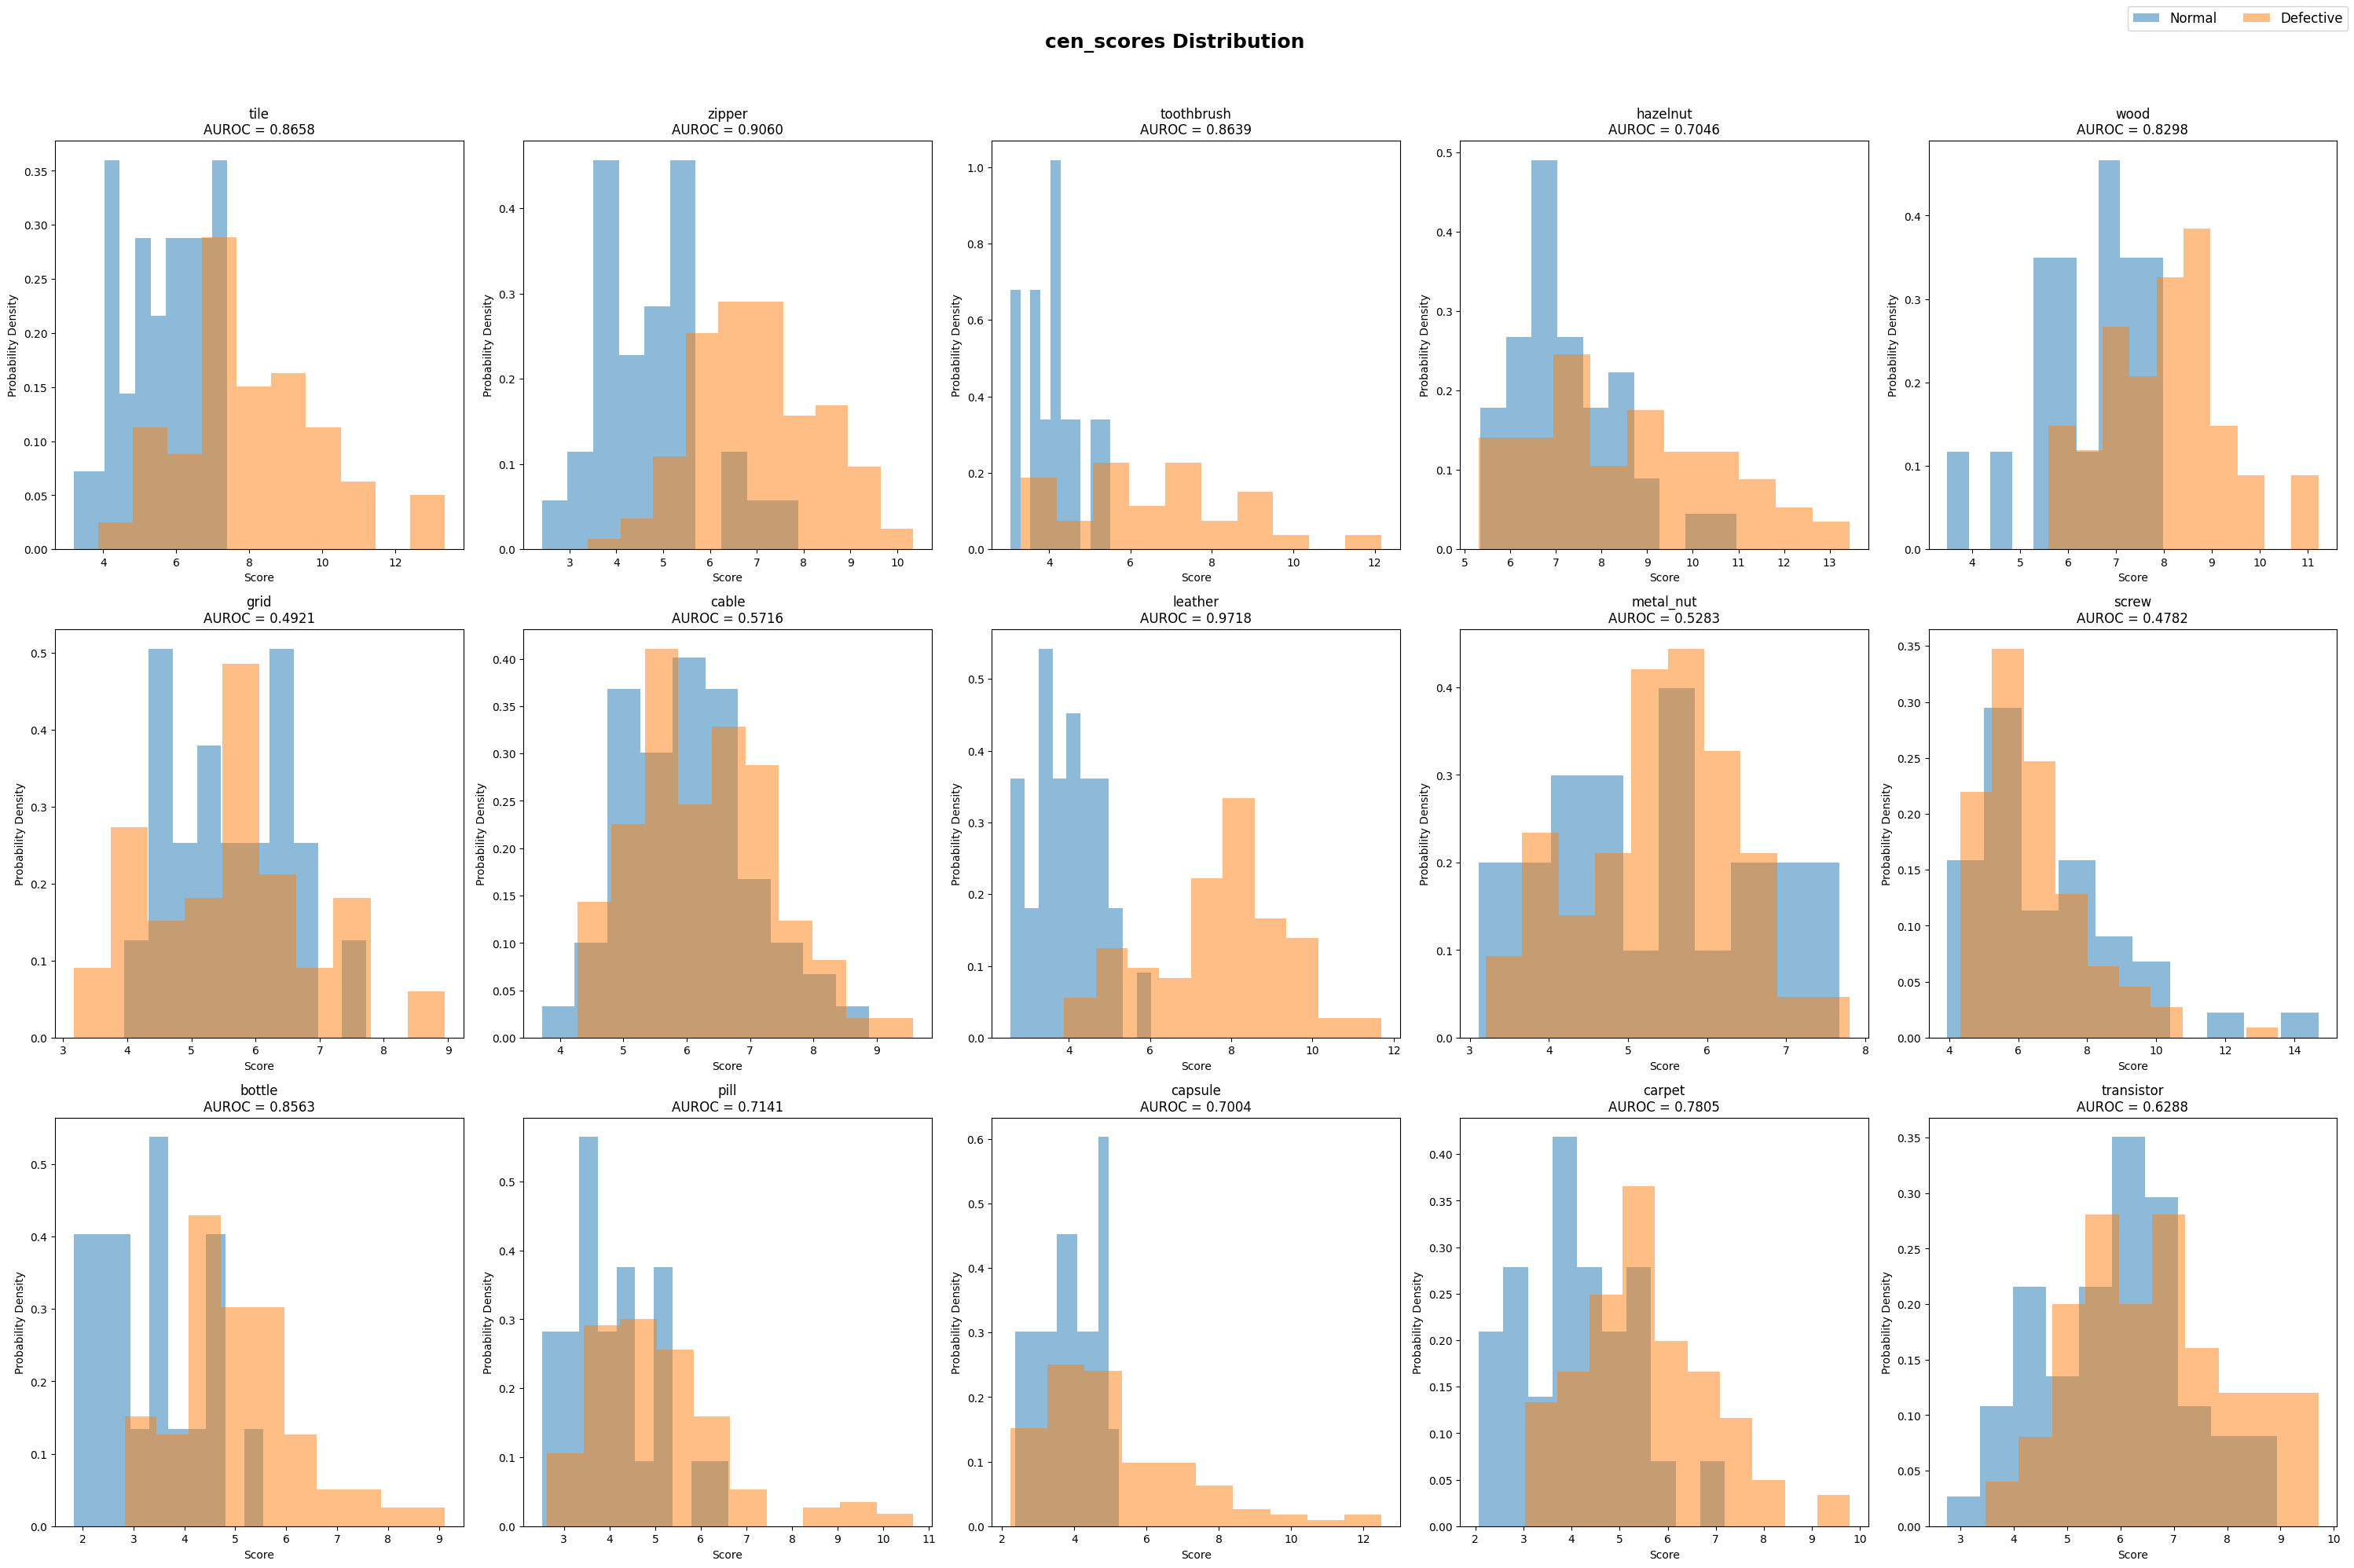

In [6]:
cen_aurocs = score_plots(score_type="cen_scores")

The centroid based method has reasonable perfomance across serveral categories, however there is a noticebale overlapo between the score distributions of normla and defevtive samples. This indicates that the diostance form the centroid alone is not enough to fully describe the embedding space. While the cnetoird get the average location of normal samples, it does not take into account for the spread or covariance of the distribution, meannig some anomalous samples to recieve scores similiar to normal samples. 

#

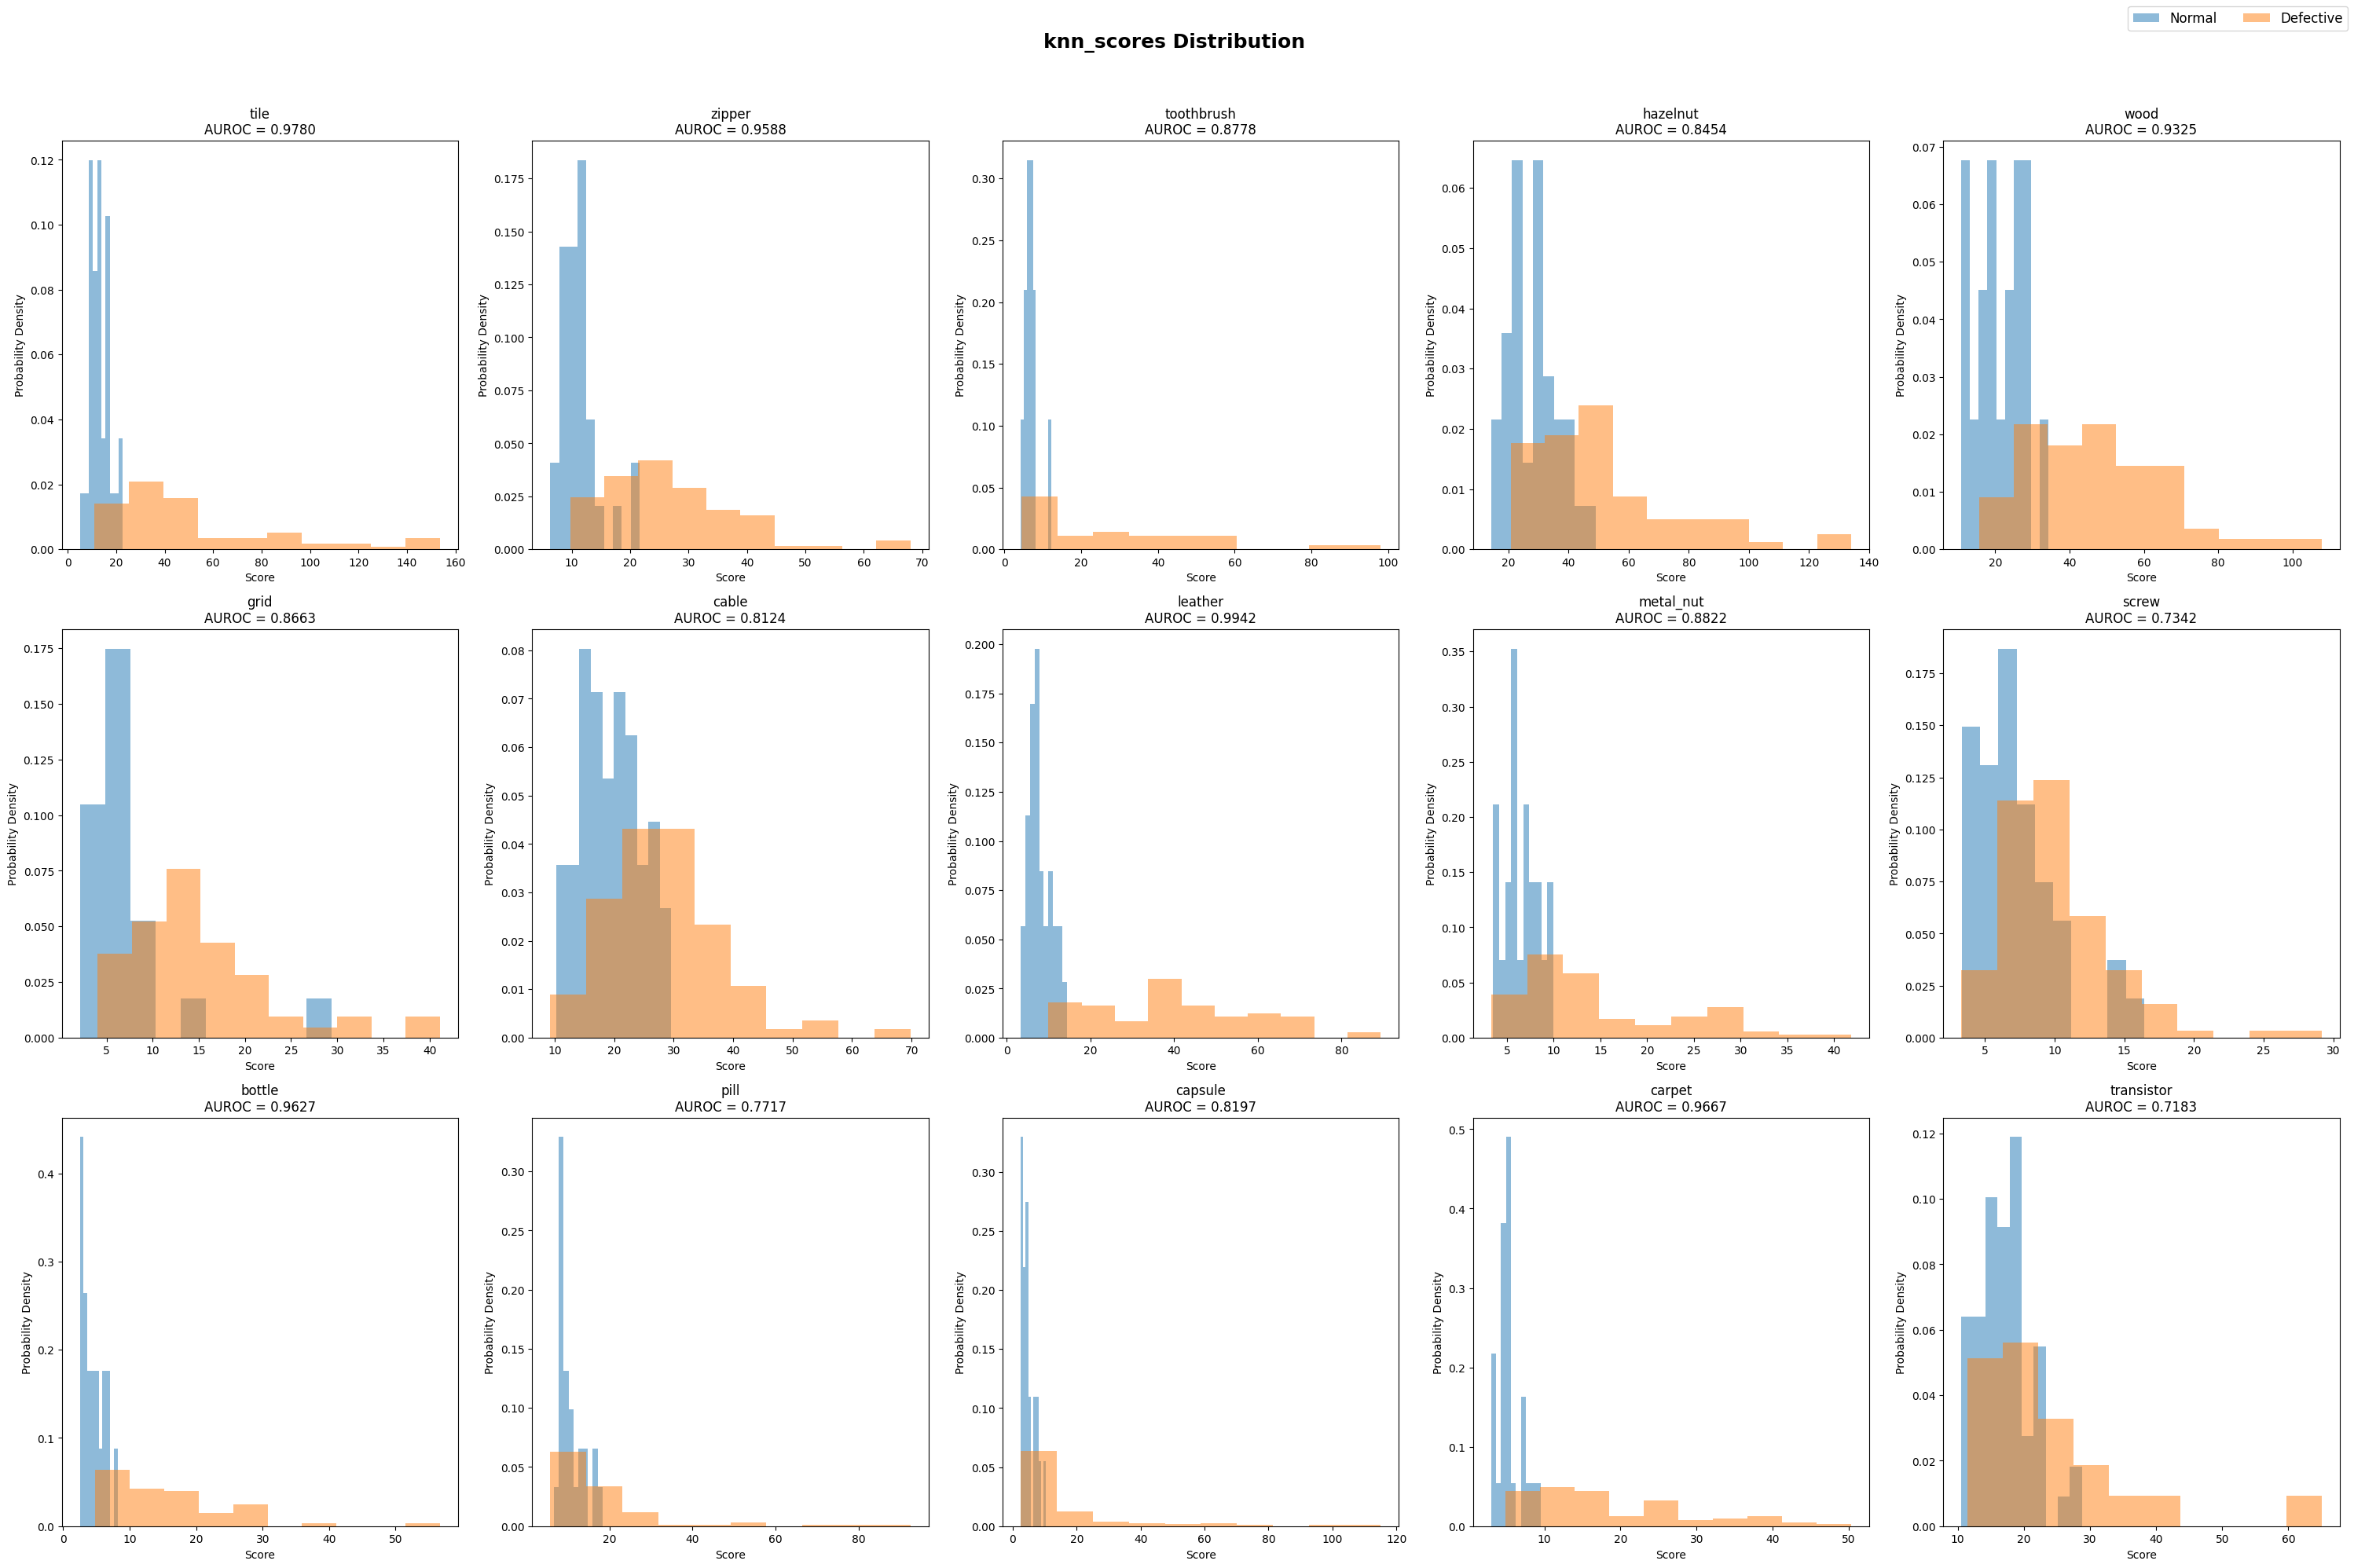

In [7]:
nn_aurocs = score_plots(score_type="knn_scores")

The K-Nearest Neighbour approach improves upon the centroid-based method by producing clearer separation between the score distributions of normal and defective samples. With the leather category having a perfect speration achieving an AUROC of 1.0. This suggests that anomalous samples are characterised by their distance to nearby normal samples than by their distance to a single global centroid. The results indicate that normal and defective samples occupy distinct regions of the embedding space, allowing KNN to identify anomalies through local neighbourhood structure rather than relying solely on the overall centre of the distribution.

#

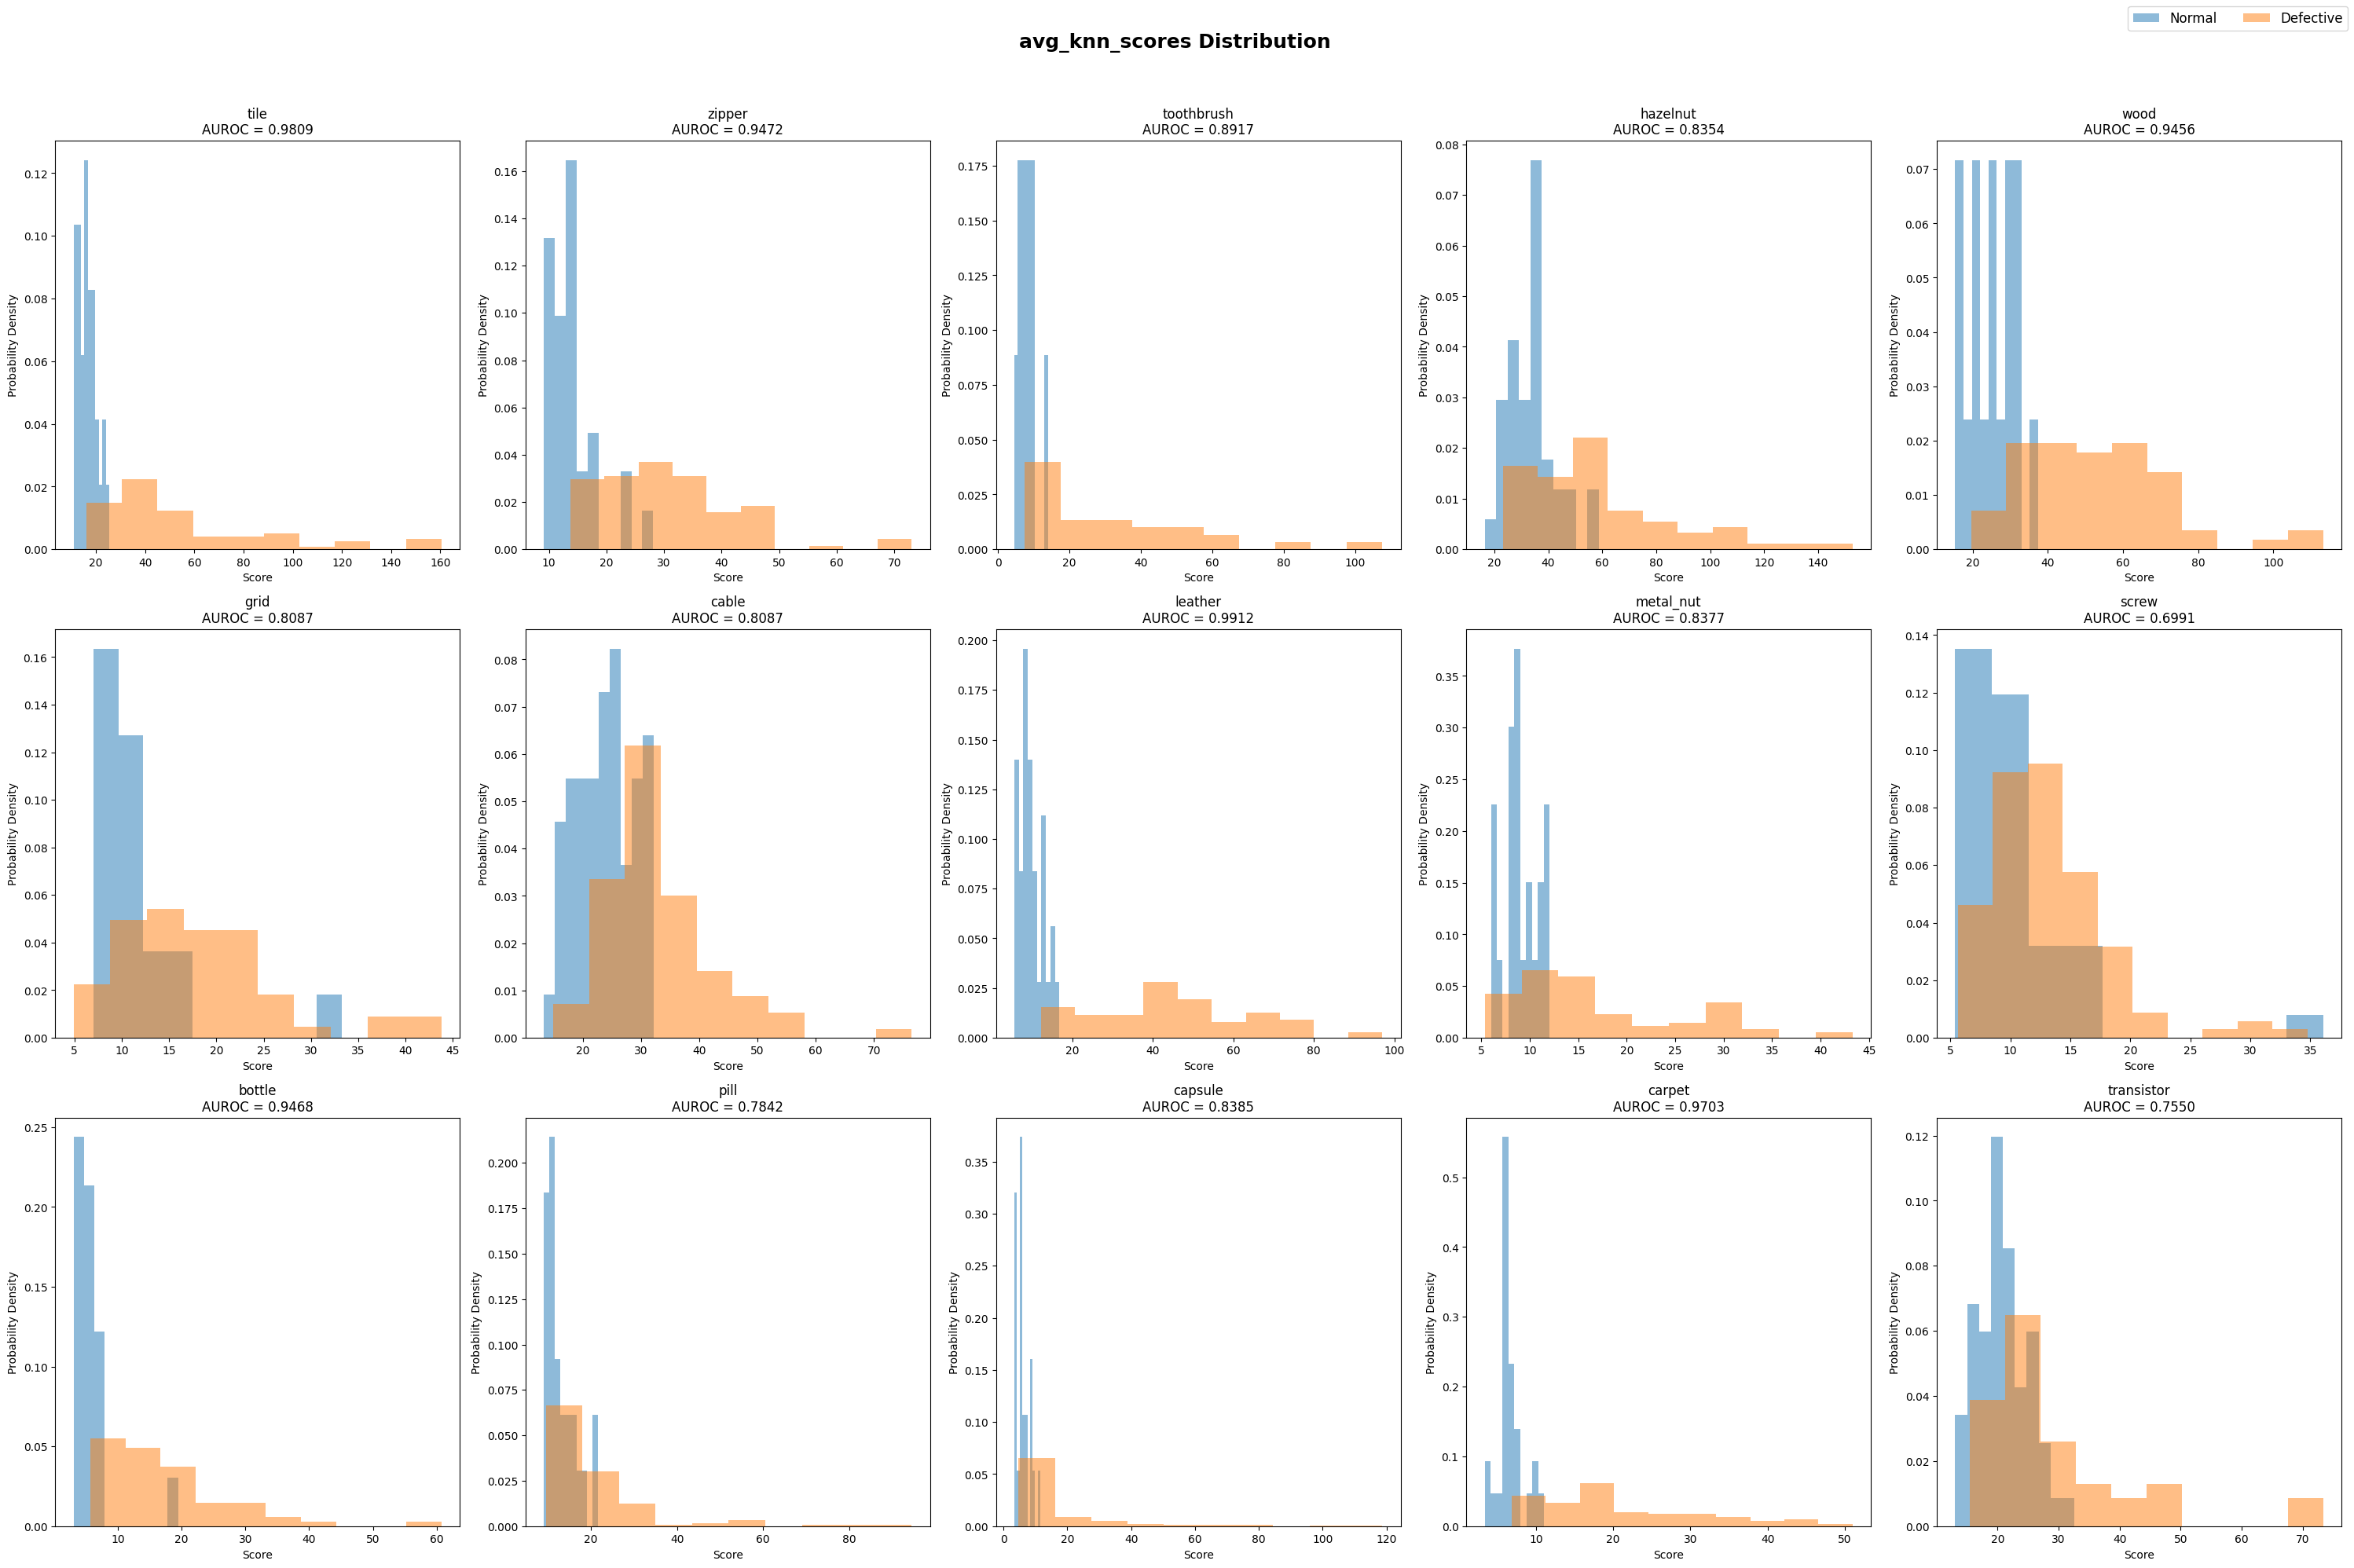

In [8]:
avg_nn_aurocs = score_plots(score_type="avg_knn_scores")

Average KNN does not improve upon the performance of standard KNN and achieves a lower average AUROC across the dataset. This suggests that the nearest normal neighbour contains the most informative signal for anomaly detection. By averaging across multiple neighbours, the anomaly score becomes influenced by additional normal samples that may lie further away in the embedding space, reducing the contrast between normal and defective samples. As a result, the score distributions exhibit greater overlap, leading to weaker separation and reduced anomaly detection performance.

#

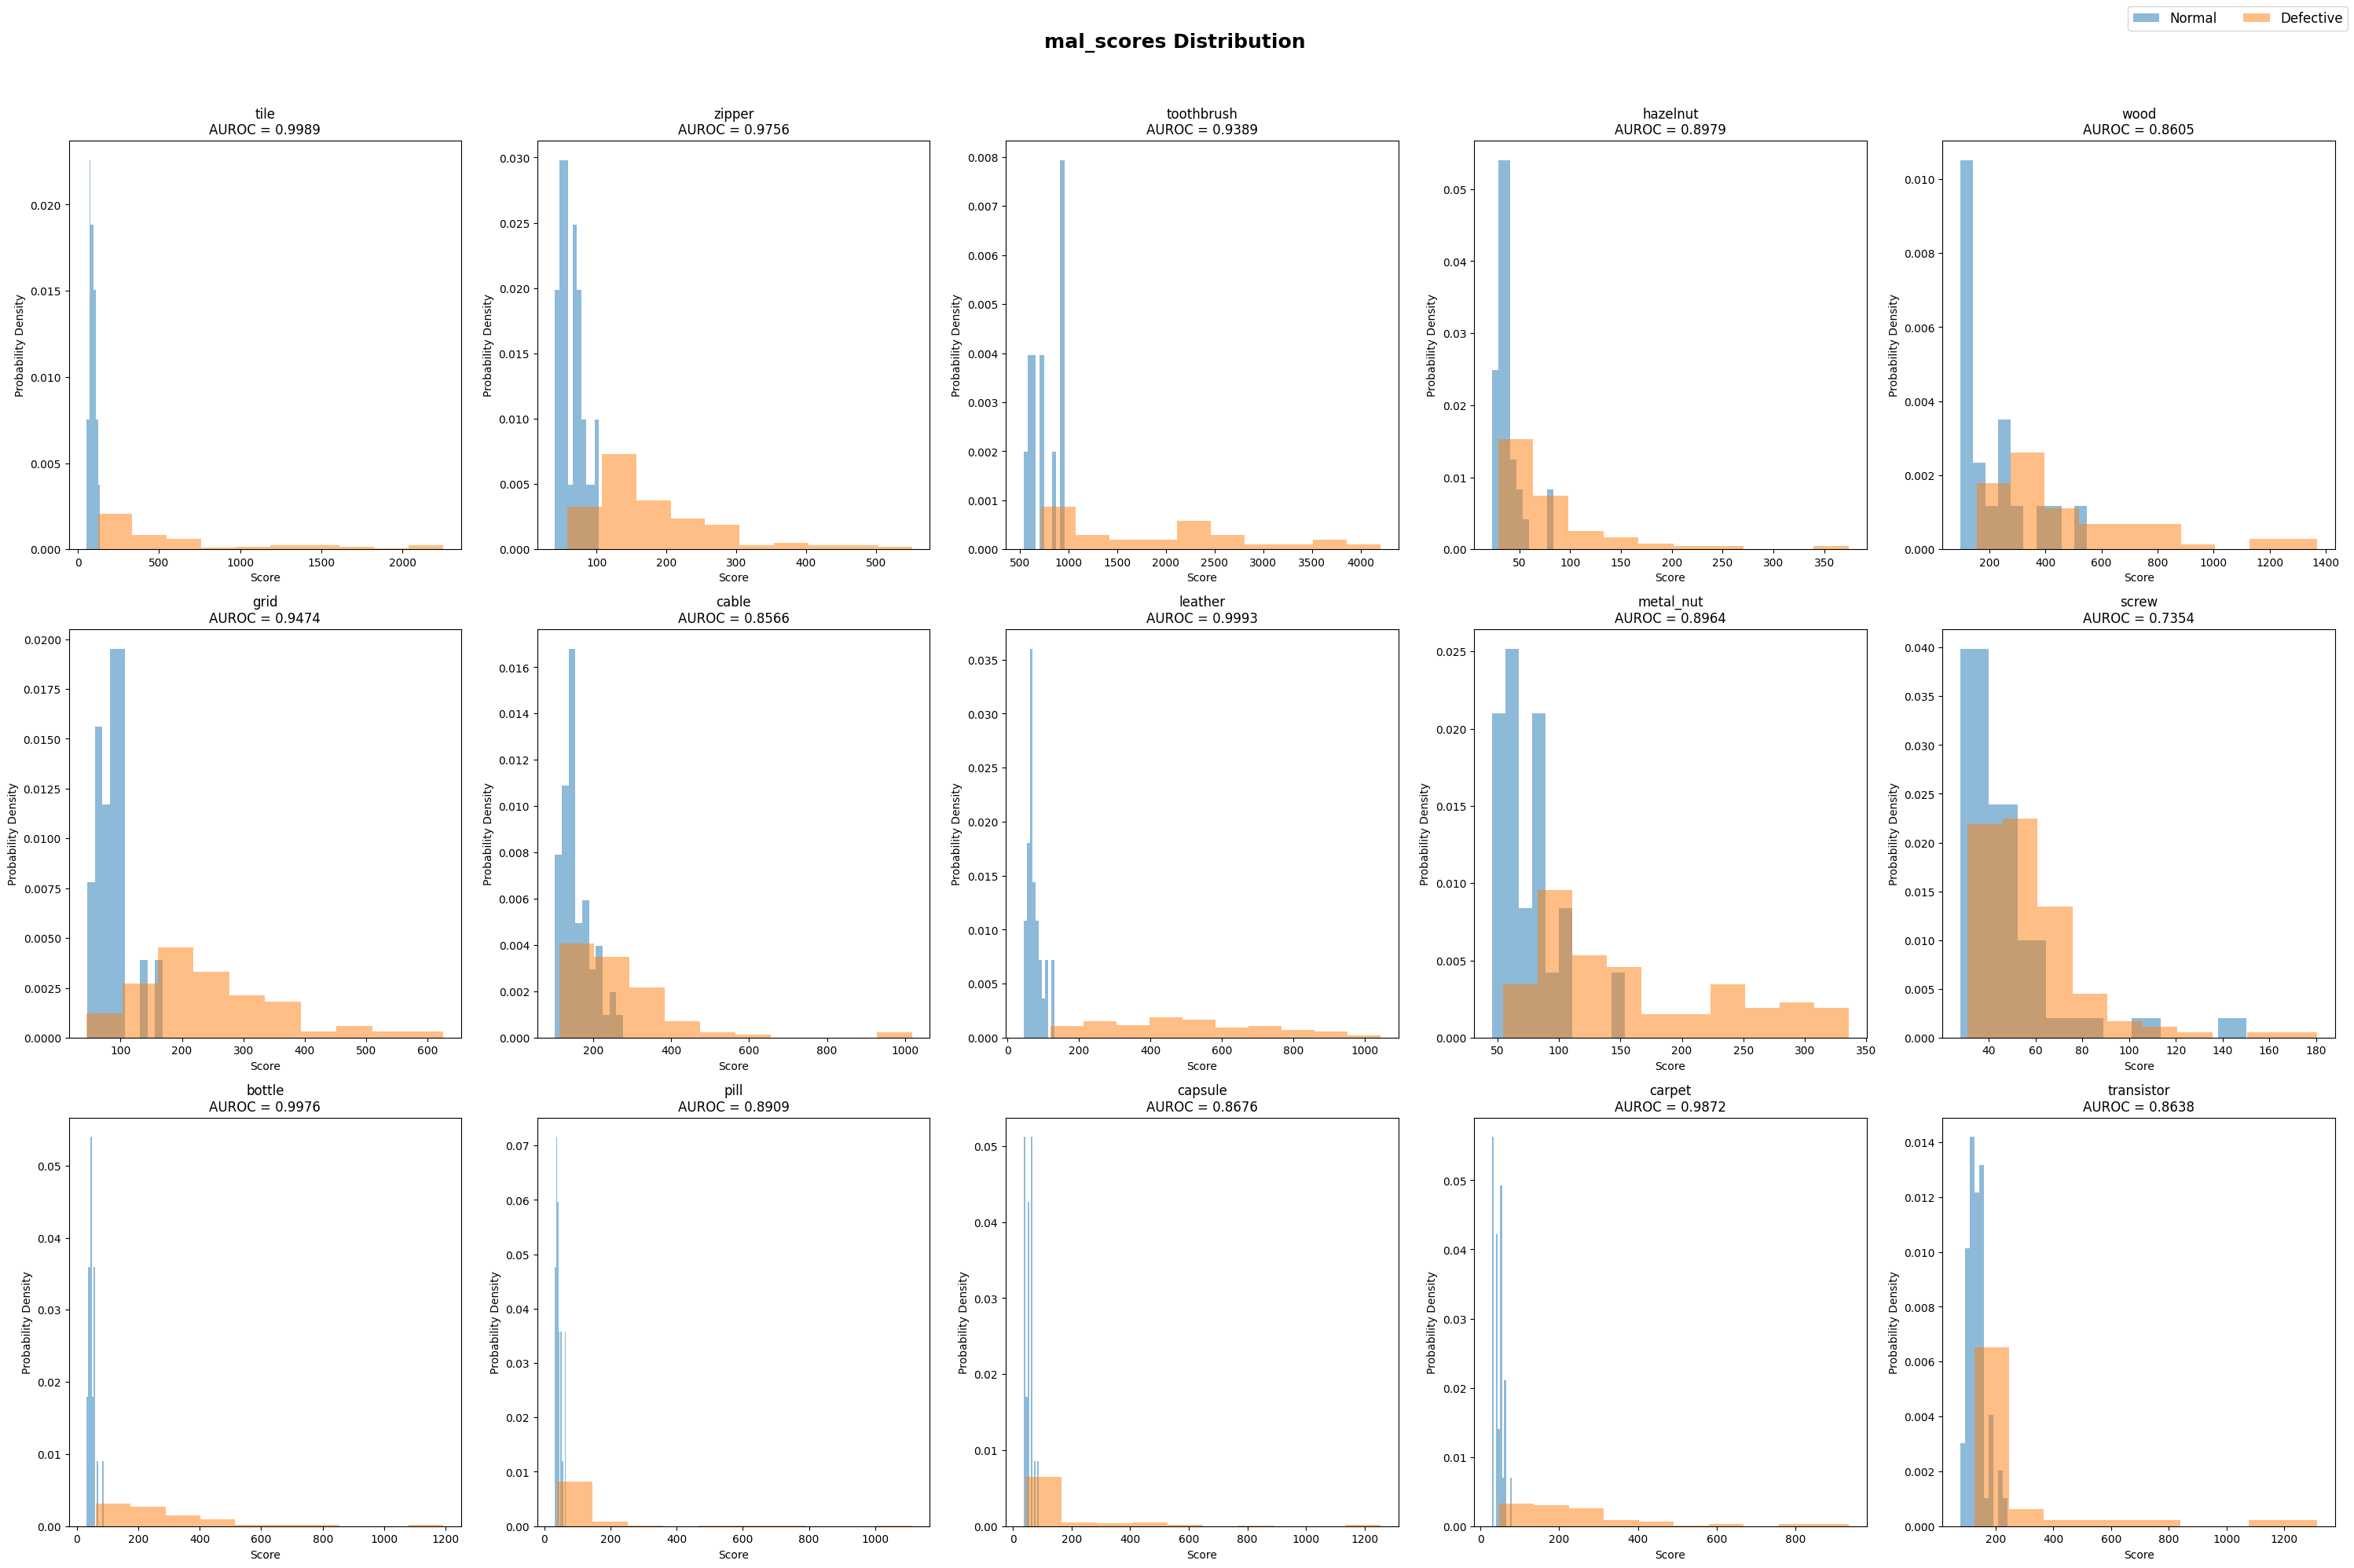

In [9]:
mal_aurocs = score_plots(score_type="mal_scores")

The Mahalanobis score performed best among all evaluated methods, achieving perfect separation between normal and defective samples in several categories, including bottle, leather, and tile. It also achieved the highest average AUROC across all categories except screw, making it the preferred anomaly scoring method for this study. Furthermore, the categories exhibiting perfect separation could be used as control groups in future experiments to evaluate whether proposed modifications improve anomaly detection performance or instead degrade the structure and separability of the embedding space.

#

In [10]:
df_rocs = pd.DataFrame({
    "cen_aurocs": cen_aurocs,
    "knn_aurocs": nn_aurocs,
    "avg_knn_aurocs": avg_nn_aurocs,
    "mal_aurocs": mal_aurocs
})

round_rocs = df_rocs.round(3)
round_rocs.to_csv(RESULTS_DIR / "aurocs.csv")

df_rocs

,cen_aurocs,knn_aurocs,avg_knn_aurocs,mal_aurocs
tile,0.865801,0.977994,0.980880,0.998918
zipper,0.905987,0.958771,0.947216,0.975578
toothbrush,0.863889,0.877778,0.891667,0.938889
hazelnut,0.704643,0.845357,0.835357,0.897857
wood,0.829825,0.932456,0.945614,0.860526
grid,0.492063,0.866332,0.808688,0.947368
cable,0.571589,0.812406,0.808658,0.856634
leather,0.971807,0.994226,0.991168,0.999321
metal_nut,0.528348,0.882209,0.837732,0.896383
screw,0.478172,0.734167,0.699119,0.735397


In [11]:
df_roc_stats = pd.DataFrame({
    "mean": df_rocs.mean(),
    "median": df_rocs.median(),
    "std": df_rocs.std(),
    "min_cat": df_rocs.idxmin(),
    "min": df_rocs.min(),
    "max_cat": df_rocs.idxmax(),
    "max": df_rocs.max()
}).round(3)

df_roc_stats.to_csv(RESULTS_DIR / "auroc_stats.csv")
df_roc_stats

,mean,median,std,min_cat,min,max_cat,max
cen_aurocs,0.726,0.714,0.159,screw,0.478,leather,0.972
knn_aurocs,0.875,0.878,0.090,transistor,0.718,leather,0.994
avg_knn_aurocs,0.869,0.838,0.091,screw,0.699,leather,0.991
mal_aurocs,0.914,0.898,0.074,screw,0.735,leather,0.999


Despite strong overall performance, categories such as screw achieved lower AUROC values across multiple scoring methods. This suggests that normal and defective samples occupy more similar regions of the embedding space, making anomaly detection more challenging. These categories provide useful benchmarks for evaluating future improvements, as successful methods should increase separability in these difficult cases.

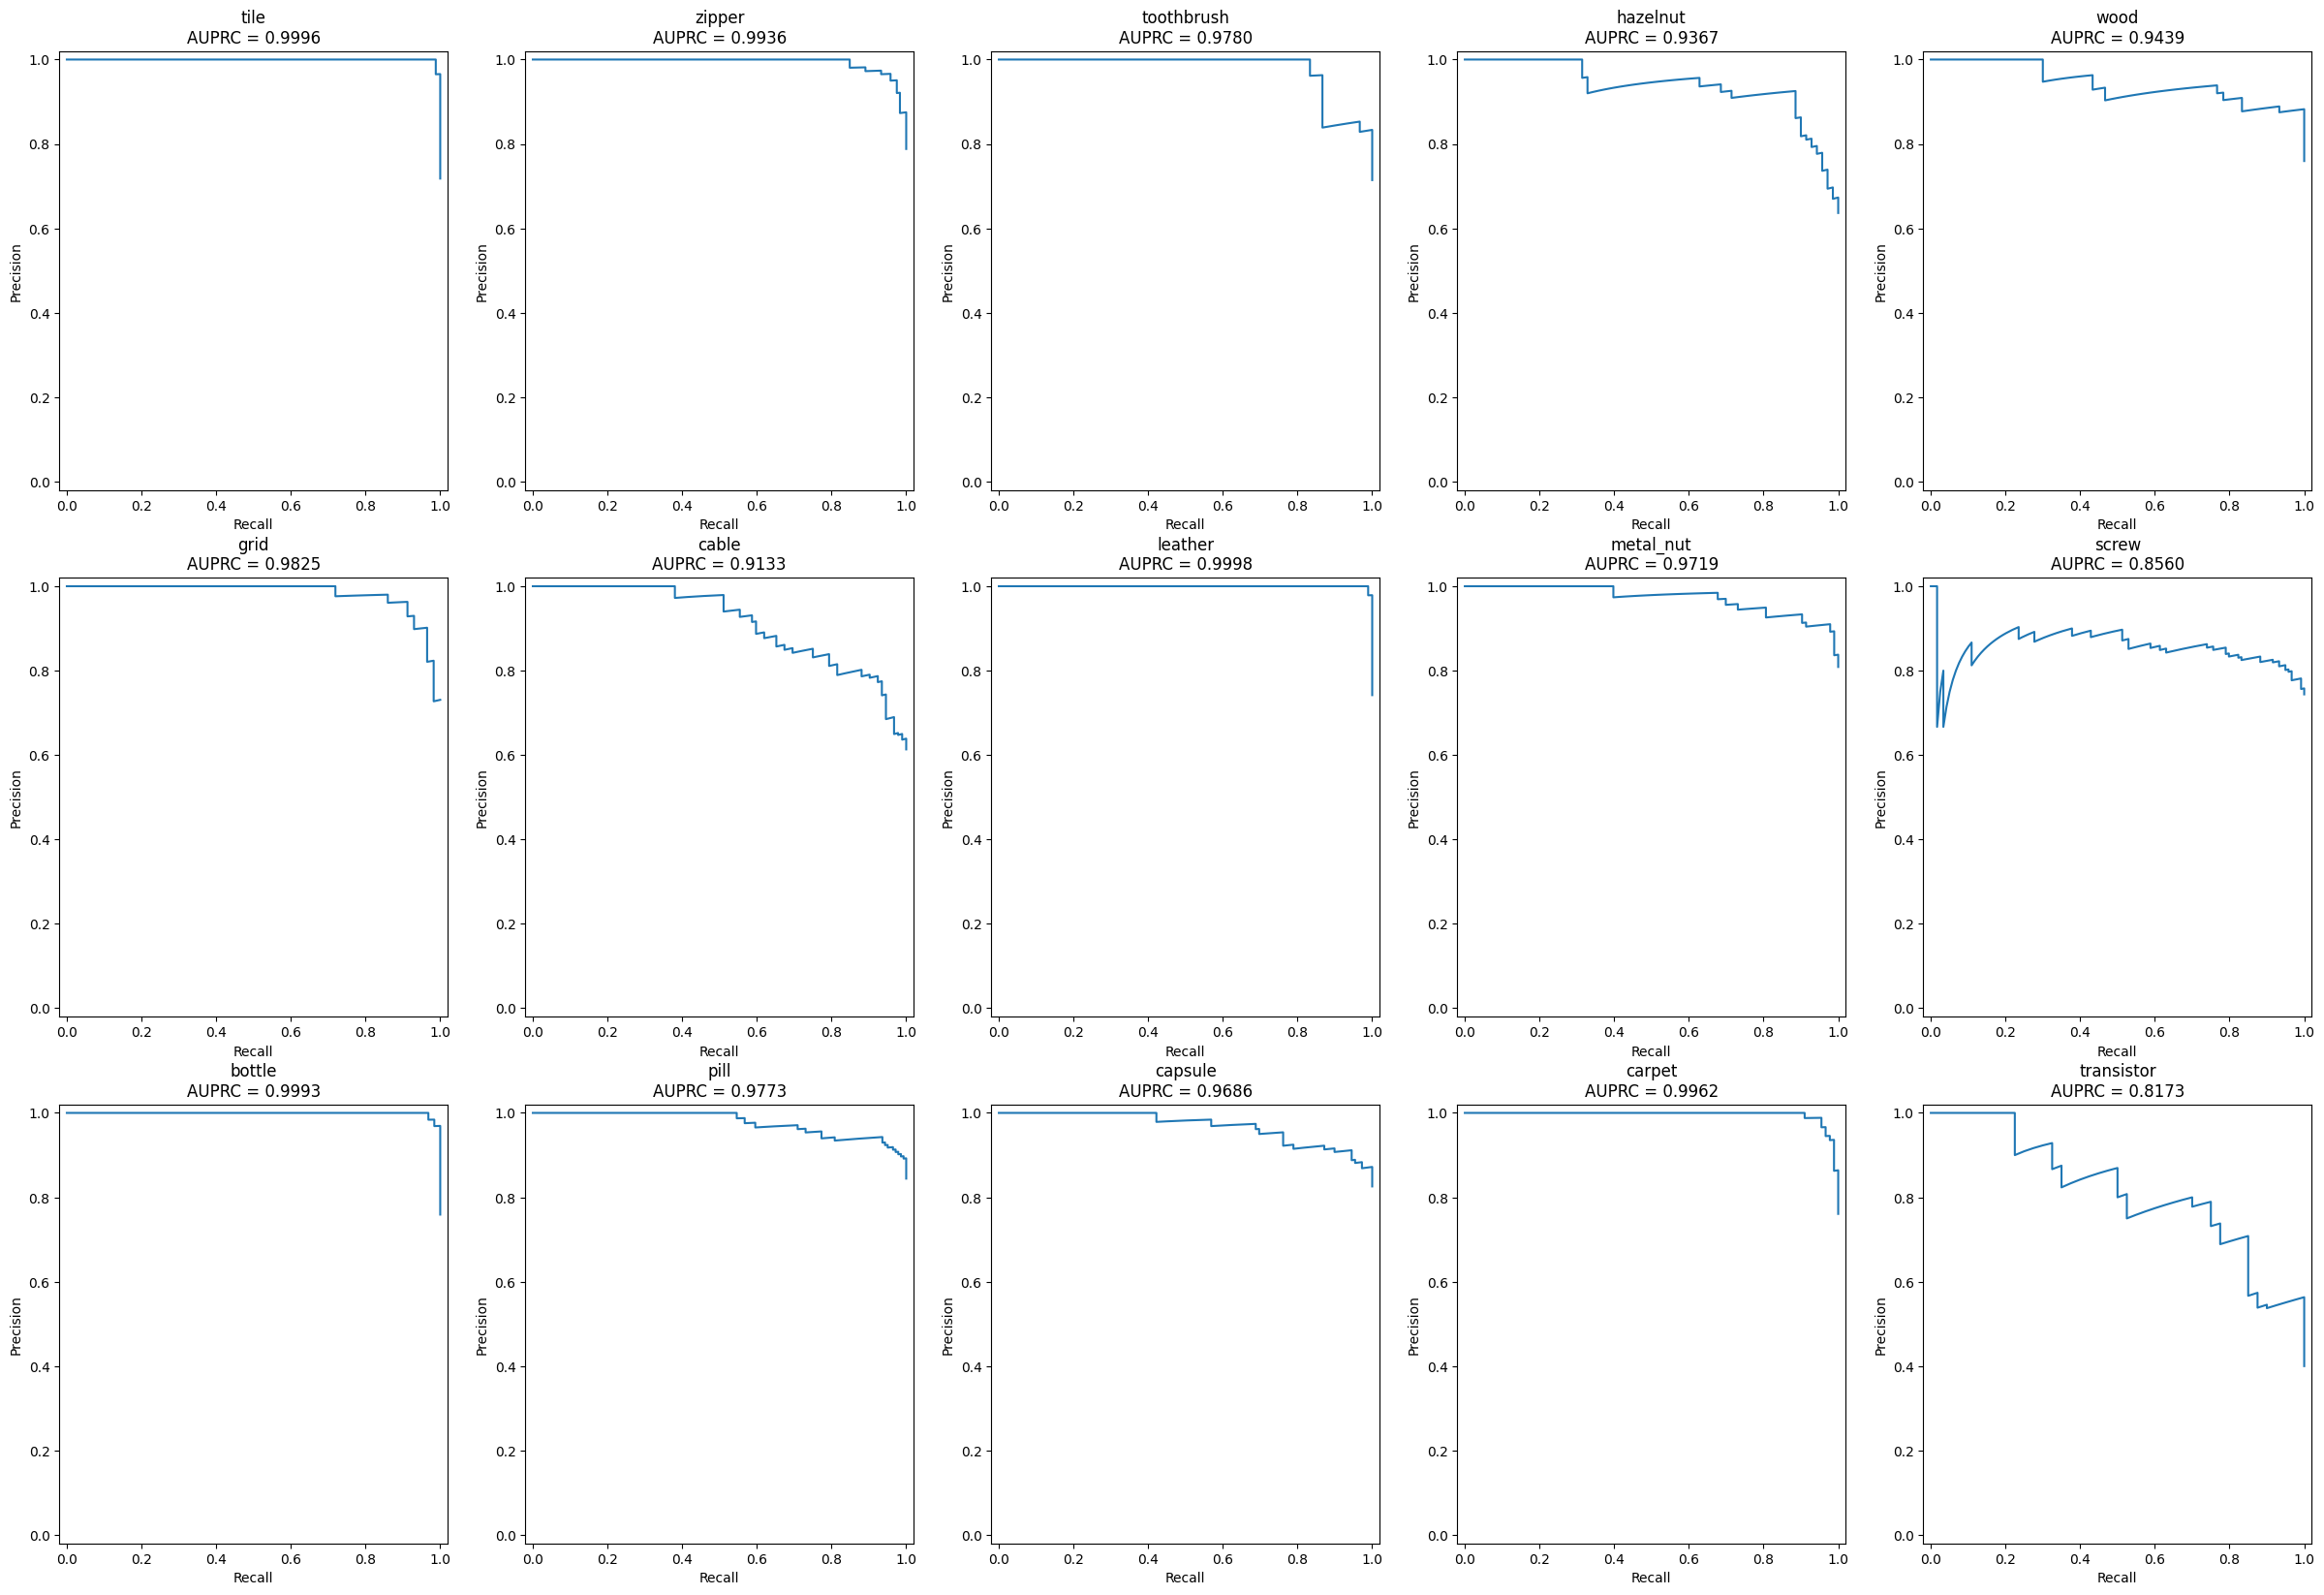

In [12]:
_, axes = plt.subplots(3, 5, figsize=(30, 20))

axes = axes.flatten()

auc_pr = {}

for i, category in enumerate(results.keys()):
    ax = axes[i]

    scores = results[category]["mal_scores"]
    labels = results[category]["labels"]

    prc = average_precision_score(labels, scores)
    auc_pr[category] = prc 
    
    precision, recall, _ = precision_recall_curve(labels, scores)

    ax.plot(recall, precision)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{category}\nAUPRC = {prc:.4f}")

plt.savefig(f"{IMAGE_DIR}/mal_auprc.svg")
plt.show()

In [13]:
df_prc = pd.DataFrame.from_dict(auc_pr, orient="index", columns=["AUPRC"])

df_prc_stats = pd.DataFrame({
    "mean": df_prc.mean(),
    "median": df_prc.median(),
    "std": df_prc.std(),
    "min_cat": df_prc.idxmin(),
    "min": df_prc.min(),
    "max_cat": df_prc.idxmax(),
    "max": df_prc.max()
})

df_prc_stats.to_csv(RESULTS_DIR / "prc_stats.csv")
df_prc_stats

,mean,median,std,min_cat,min,max_cat,max
AUPRC,0.955588,0.977276,0.055012,transistor,0.817267,leather,0.999769
